# Learning when silence has no click: Online SDFT with Liquid LFM

This notebook runs a real
[`LiquidAI/LFM2.5-230M`](https://huggingface.co/LiquidAI/LFM2.5-230M)
student. It is **repository-independent**: it contains the complete simulator,
policies, and analysis and reads no repository files. Its setup cell downloads
the `LiquidAI/LFM2.5-230M` checkpoint and Python packages on first use.

## Choose a reading path

| If you want to… | Jump to |
| --- | --- |
| See the answer first | [1. Results at a glance](#1-results-at-a-glance) |
| Understand the interaction visually | [2. Watch one causal round](#2-watch-one-causal-round) |
| Put yourself in the decision | [3. Play the router](#3-play-the-router) |
| Check why the setup is realistic | [4. Understand the setting](#4-understand-the-setting) |
| Compare Online-SFT and Online-SDFT | [5. Compare the methods](#5-compare-the-methods) |
| Reproduce everything | [6. Reproduce the experiment](#6-reproduce-the-experiment-optional) |
| Inspect curves and audits | [7. Metrics](#7-inspect-the-metrics-optional) · [8. Audits](#8-audit-the-realism-optional) |

> Long code cells are collapsed by default where the notebook viewer supports it. Expand only the implementation details you want.

## 1. Results at a glance

Every one of the 240 decisions counts, including cold start and exploration.
Mean over 3 paired streams:

| Method | Online accuracy | Cumulative regret ↓ |
| --- | ---: | ---: |
| Base | 37.08% ± 3.30 | 81.50 ± 2.24 |
| ICL | 37.50% ± 1.25 | 81.10 ± 1.37 |
| RAG | 38.75% ± 0.47 | 79.94 ± 7.38 |
| REINFORCE | 32.08% ± 1.70 | 115.65 ± 16.88 |
| Online-SFT | 41.94% ± 2.72 | 97.65 ± 13.23 |
| **Online-SDFT** | **64.72% ± 3.14** | **36.24 ± 1.66** |

**Short conclusion:** the full soft teacher distribution is a substantially better online target than one sampled hard action or scalar reward. Stop here if you only need the result.

## 2. Watch one causal round

The animation shows the non-cheating order: predict, commit and score, observe one factual world, then learn for the next round.

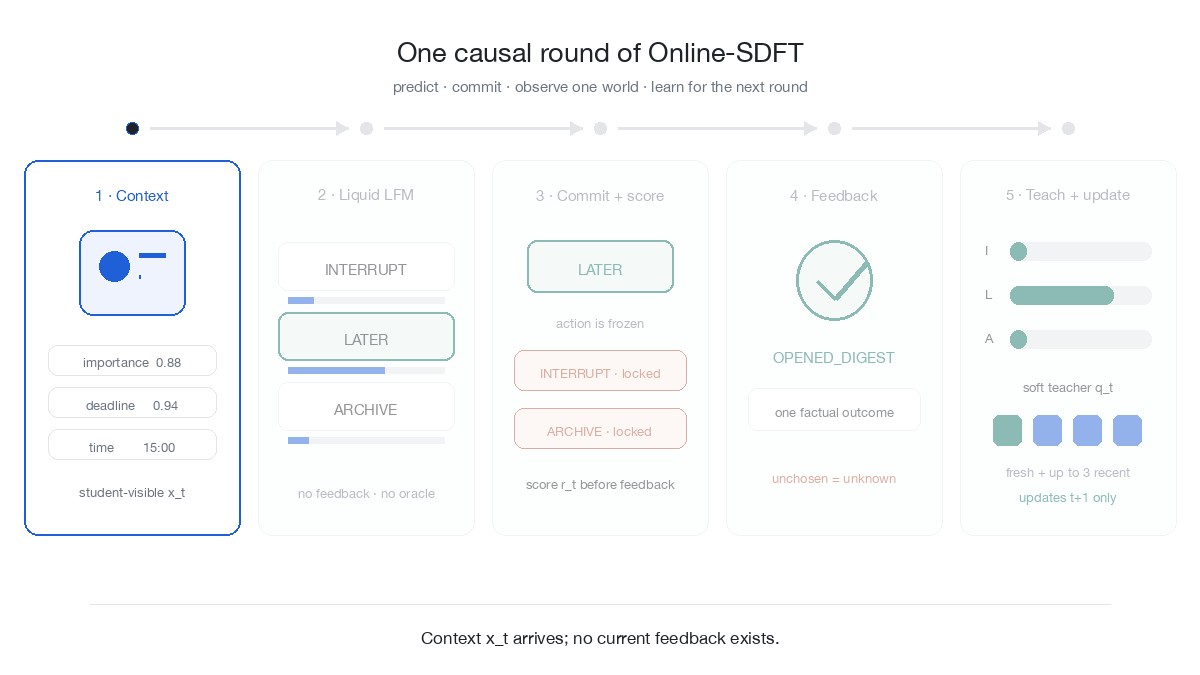

In [ ]:
# @title Generate the in-memory Online-SDFT animation { display-mode: "form" }
from io import BytesIO
from PIL import Image as PILImage, ImageDraw, ImageFont
from matplotlib import font_manager
import matplotlib.pyplot as plt

GIF_WIDTH, GIF_HEIGHT = 1200, 675
PALETTE = {
    "bg": "#FFFFFF",
    "navy": "#1F2328",
    "blue": "#1F5FD8",
    "teal": "#0F6F63",
    "coral": "#B4573F",
    "slate": "#6B7280",
    "line": "#E3E5E9",
    "pale_blue": "#EEF3FD",
    "pale_teal": "#EAF3F1",
    "pale_coral": "#FAEFEB",
    "white": "#FFFFFF",
}


def _font(size, bold=False):
    weight = "bold" if bold else "normal"
    # Prefer a grotesque that matches the article; DejaVu is the portable
    # fallback that always ships with matplotlib (e.g. on Colab).
    path = font_manager.findfont(
        font_manager.FontProperties(
            family=[
                "Helvetica Neue",
                "Helvetica",
                "Arial",
                "Liberation Sans",
                "DejaVu Sans",
            ],
            weight=weight,
        ),
        fallback_to_default=True,
    )
    return ImageFont.truetype(path, size=size)


FONTS = {
    "title": _font(27, True),
    "heading": _font(15, True),
    "body": _font(15),
    "body_bold": _font(15, True),
    "small": _font(13),
    "status": _font(17),
}


def _rgb(hex_color):
    value = hex_color.lstrip("#")
    return tuple(int(value[i:i + 2], 16) for i in (0, 2, 4))


def _blend(foreground, background, alpha):
    fg, bg = _rgb(foreground), _rgb(background)
    return tuple(round(alpha * f + (1 - alpha) * b) for f, b in zip(fg, bg))


def _center(draw, xy, text, font, fill):
    box = draw.textbbox((0, 0), text, font=font)
    width = box[2] - box[0]
    height = box[3] - box[1]
    draw.text((xy[0] - width / 2, xy[1] - height / 2), text, font=font, fill=fill)


def _arrow(draw, start, end, fill, width=4):
    draw.line((start, end), fill=fill, width=width)
    x, y = end
    direction = 1 if end[0] >= start[0] else -1
    draw.polygon(
        [(x, y), (x - 12 * direction, y - 7), (x - 12 * direction, y + 7)],
        fill=fill,
    )


def _pill(draw, box, text, fill, outline, text_fill, font=None, width=1):
    font = font or FONTS["body_bold"]
    draw.rounded_rectangle(box, radius=10, fill=fill, outline=outline, width=width)
    _center(draw, ((box[0] + box[2]) / 2, (box[1] + box[3]) / 2), text, font, text_fill)


def _card(draw, box, title, intensity, active=False):
    outline = (
        PALETTE["blue"] if active
        else _blend(PALETTE["line"], PALETTE["bg"], max(0.45, intensity))
    )
    fill = PALETTE["white"] if active else _blend("#FBFCFD", PALETTE["bg"], intensity)
    draw.rounded_rectangle(box, radius=14, fill=fill, outline=outline,
                           width=2 if active else 1)
    label_color = (
        PALETTE["blue"] if active
        else _blend(PALETTE["slate"], PALETTE["bg"], intensity)
    )
    _center(draw, ((box[0] + box[2]) / 2, box[1] + 32), title,
            FONTS["heading"], label_color)


def _draw_context(draw, box, intensity):
    color = _blend(PALETTE["blue"], PALETTE["bg"], intensity)
    x1, y1, x2, _ = box
    draw.rounded_rectangle((x1 + 55, y1 + 70, x2 - 55, y1 + 155), radius=14,
                           fill=_blend(PALETTE["pale_blue"], PALETTE["bg"], intensity),
                           outline=color, width=2)
    draw.ellipse((x1 + 75, y1 + 91, x1 + 105, y1 + 121), fill=color)
    draw.line((x1 + 115, y1 + 95, x2 - 75, y1 + 95), fill=color, width=5)
    draw.line((x1 + 115, y1 + 116, x2 - 100, y1 + 116), fill=color, width=4)
    labels = ["importance  0.88", "deadline     0.94", "time        15:00"]
    for index, label in enumerate(labels):
        y = y1 + 185 + index * 42
        _pill(draw, (x1 + 24, y, x2 - 24, y + 30), label,
              _blend(PALETTE["white"], PALETTE["bg"], intensity),
              _blend(PALETTE["line"], PALETTE["bg"], intensity),
              _blend(PALETTE["slate"], PALETTE["bg"], intensity), FONTS["small"])
    _center(draw, ((x1 + x2) / 2, y1 + 330), "student-visible x_t",
            FONTS["small"], _blend(PALETTE["slate"], PALETTE["bg"], intensity))


def _draw_student(draw, box, intensity):
    x1, y1, x2, _ = box
    labels = [("INTERRUPT", 0.18), ("LATER", 0.67), ("ARCHIVE", 0.15)]
    for index, (label, probability) in enumerate(labels):
        y = y1 + 82 + index * 70
        selected = label == "LATER"
        fill = PALETTE["pale_teal"] if selected else PALETTE["white"]
        outline = PALETTE["teal"] if selected else PALETTE["line"]
        _pill(draw, (x1 + 20, y, x2 - 20, y + 48), label,
              _blend(fill, PALETTE["bg"], intensity),
              _blend(outline, PALETTE["bg"], intensity),
              _blend(PALETTE["navy"], PALETTE["bg"], intensity),
              width=2 if selected else 1)
        draw.rectangle((x1 + 30, y + 55, x1 + 30 + 145 * probability, y + 61),
                       fill=_blend(PALETTE["blue"], PALETTE["bg"], intensity))
        draw.rectangle((x1 + 30 + 145 * probability, y + 55, x2 - 30, y + 61),
                       fill=_blend(PALETTE["line"], PALETTE["bg"], intensity))
    _center(draw, ((x1 + x2) / 2, y1 + 330), "no feedback · no oracle",
            FONTS["small"], _blend(PALETTE["slate"], PALETTE["bg"], intensity))


def _draw_commit(draw, box, intensity):
    x1, y1, x2, _ = box
    _pill(draw, (x1 + 35, y1 + 80, x2 - 35, y1 + 132), "LATER",
          _blend(PALETTE["pale_teal"], PALETTE["bg"], intensity),
          _blend(PALETTE["teal"], PALETTE["bg"], intensity),
          _blend(PALETTE["teal"], PALETTE["bg"], intensity), width=2)
    _center(draw, ((x1 + x2) / 2, y1 + 160), "action is frozen",
            FONTS["small"], _blend(PALETTE["slate"], PALETTE["bg"], intensity))
    for index, label in enumerate(("INTERRUPT · locked", "ARCHIVE · locked")):
        y = y1 + 190 + index * 58
        _pill(draw, (x1 + 22, y, x2 - 22, y + 40), label,
              _blend(PALETTE["pale_coral"], PALETTE["bg"], intensity),
              _blend(PALETTE["coral"], PALETTE["bg"], intensity),
              _blend(PALETTE["coral"], PALETTE["bg"], intensity), FONTS["small"])
    _center(draw, ((x1 + x2) / 2, y1 + 322), "score r_t before feedback",
            FONTS["small"], _blend(PALETTE["navy"], PALETTE["bg"], intensity))


def _draw_feedback(draw, box, intensity):
    x1, y1, x2, _ = box
    teal = _blend(PALETTE["teal"], PALETTE["bg"], intensity)
    draw.ellipse((x1 + 70, y1 + 80, x2 - 70, y1 + 160),
                 fill=_blend(PALETTE["pale_teal"], PALETTE["bg"], intensity),
                 outline=teal, width=3)
    draw.line((x1 + 91, y1 + 121, x1 + 109, y1 + 139), fill=teal, width=5)
    draw.line((x1 + 109, y1 + 139, x1 + 141, y1 + 102), fill=teal, width=5)
    _center(draw, ((x1 + x2) / 2, y1 + 195), "OPENED_DIGEST",
            FONTS["body_bold"], teal)
    _pill(draw, (x1 + 22, y1 + 228, x2 - 22, y1 + 270), "one factual outcome",
          _blend(PALETTE["white"], PALETTE["bg"], intensity),
          _blend(PALETTE["line"], PALETTE["bg"], intensity),
          _blend(PALETTE["navy"], PALETTE["bg"], intensity), FONTS["small"])
    _center(draw, ((x1 + x2) / 2, y1 + 315), "unchosen = unknown",
            FONTS["small"], _blend(PALETTE["coral"], PALETTE["bg"], intensity))


def _draw_teacher(draw, box, intensity):
    x1, y1, x2, _ = box
    values = [("I", 0.12), ("L", 0.76), ("A", 0.12)]
    for index, (label, value) in enumerate(values):
        y = y1 + 82 + index * 44
        draw.text((x1 + 25, y), label, font=FONTS["small"],
                  fill=_blend(PALETTE["navy"], PALETTE["bg"], intensity))
        draw.rounded_rectangle((x1 + 50, y, x2 - 25, y + 18), radius=8,
                               fill=_blend(PALETTE["line"], PALETTE["bg"], intensity))
        draw.rounded_rectangle((x1 + 50, y, x1 + 50 + 135 * value, y + 18), radius=8,
                               fill=_blend(PALETTE["teal"], PALETTE["bg"], intensity))
    _center(draw, ((x1 + x2) / 2, y1 + 225), "soft teacher q_t",
            FONTS["small"], _blend(PALETTE["navy"], PALETTE["bg"], intensity))
    for index in range(4):
        left = x1 + 33 + index * 40
        fill = PALETTE["teal"] if index == 0 else PALETTE["blue"]
        draw.rounded_rectangle((left, y1 + 255, left + 28, y1 + 285), radius=6,
                               fill=_blend(fill, PALETTE["bg"], intensity))
    _center(draw, ((x1 + x2) / 2, y1 + 310), "fresh + up to 3 recent",
            FONTS["small"], _blend(PALETTE["slate"], PALETTE["bg"], intensity))
    _center(draw, ((x1 + x2) / 2, y1 + 335), "updates t+1 only",
            FONTS["small"], _blend(PALETTE["teal"], PALETTE["bg"], intensity))


def _draw_frame(progress):
    image = PILImage.new("RGB", (GIF_WIDTH, GIF_HEIGHT), PALETTE["bg"])
    draw = ImageDraw.Draw(image)

    _center(draw, (GIF_WIDTH / 2, 46), "One causal round of Online-SDFT",
            FONTS["title"], PALETTE["navy"])
    _center(draw, (GIF_WIDTH / 2, 84),
            "predict · commit · observe one world · learn for the next round",
            FONTS["body"], PALETTE["slate"])

    left, gap, card_width = 24, 18, 216
    cards = [(left + index * (card_width + gap), 160,
              left + index * (card_width + gap) + card_width, 535)
             for index in range(5)]
    centers = [((box[0] + box[2]) / 2, 128) for box in cards]
    for index in range(4):
        _arrow(draw, (centers[index][0] + 18, 128),
               (centers[index + 1][0] - 18, 128), PALETTE["line"], 3)

    current = min(4, int(progress))
    for index, (cx, cy) in enumerate(centers):
        fill = PALETTE["blue"] if index <= current else PALETTE["line"]
        draw.ellipse((cx - 8, cy - 8, cx + 8, cy + 8), fill=fill,
                     outline=PALETTE["white"], width=2)

    if progress < 4:
        start = centers[int(progress)][0]
        finish = centers[int(progress) + 1][0]
        fraction = progress - int(progress)
        dot_x = start + (finish - start) * fraction
    else:
        dot_x = centers[-1][0]
    draw.ellipse((dot_x - 5, 123, dot_x + 5, 133), fill=PALETTE["navy"])

    titles = ("1 · Context", "2 · Liquid LFM", "3 · Commit + score",
              "4 · Feedback", "5 · Teach + update")
    renderers = (_draw_context, _draw_student, _draw_commit, _draw_feedback, _draw_teacher)
    for index, box in enumerate(cards):
        if index < current:
            intensity = 0.82
        elif index == current:
            intensity = 1.0
        else:
            intensity = 0.48
        _card(draw, box, titles[index], intensity, active=index == current)
        renderers[index](draw, box, intensity)

    if current == 4:
        _center(draw, (GIF_WIDTH / 2, 551), "the updated policy faces the next context",
                FONTS["small"], PALETTE["blue"])
        _arrow(draw, (cards[4][2] - 15, 574), (cards[0][0] + 15, 574), PALETTE["blue"], 2)

    status = (
        "Context x_t arrives; no current feedback exists.",
        "Liquid LFM selects its own action from π_t(.|x_t).",
        "The selected action and regret are frozen before feedback.",
        "Only the selected action produces factual feedback.",
        "The teacher's soft target updates a tiny batch for t+1.",
    )[current]
    draw.line((90, 604, 1110, 604), fill=PALETTE["line"], width=1)
    _center(draw, (600, 634), status, FONTS["status"], PALETTE["navy"])
    return image


def make_online_sdft_gif():
    frames = []
    for stage in range(5):
        for substep in range(7):
            progress = stage + substep / 7 if stage < 4 else 4
            frames.append(_draw_frame(progress))
        pause_progress = stage + 0.99 if stage < 4 else 4.0
        frames.extend([_draw_frame(pause_progress)] * 2)
    buffer = BytesIO()
    frames[0].save(buffer, format="GIF", save_all=True,
                   append_images=frames[1:], duration=135, loop=0,
                   optimize=True, disposal=2)
    return buffer.getvalue()

from IPython.display import Image as NotebookImage, Markdown, display
gif_bytes = make_online_sdft_gif()
display(NotebookImage(data=gif_bytes))

### 2.1 What the animation establishes

- The student acts without current feedback or privileged telemetry.
- The score is frozen before the user outcome exists.
- Only the selected route produces feedback; unchosen outcomes stay unknown.
- The teacher's soft distribution updates at most four records for `t+1`.

If the student chooses `ARCHIVE`, no notification exists. The only factual outcomes are an organic inbox open or no observation—never a push or digest click.

## 3. Play the router

Choose a scenario using only the visible cues, decide what **you** would do, then edit the two values in the play cell and run it.

| ID | Notification | Visible cues |
| ---: | --- | --- |
| `0` | Afternoon calendar alert | High importance and deadline pressure |
| `1` | On-call monitoring incident | High urgency during an incident |
| `2` | Off-hours message from a close friend | Low urgency, high affinity |
| `3` | Late-morning promotion | Low importance, deadline, and affinity |

Commit mentally before revealing the outcome. The engine cell is collapsed because its hidden state would spoil the game.

In [ ]:
# @title Hidden game engine and scenario state { display-mode: "form" }
import random
from IPython.display import Markdown, display

GAME_ACTIONS = ("INTERRUPT", "LATER", "ARCHIVE")
GAME_SCENARIOS = (
    {
        "name": "Afternoon calendar alert",
        "category": "calendar", "time": "15:00",
        "importance": 0.88, "deadline": 0.94, "affinity": 0.45,
        "busy": 0.88, "incident": 0.0, "manager": 0.0, "social": 0.0,
        "seed": 7,
    },
    {
        "name": "On-call monitoring incident",
        "category": "monitoring", "time": "02:10",
        "importance": 0.82, "deadline": 0.90, "affinity": 0.25,
        "busy": 0.30, "incident": 1.0, "manager": 0.0, "social": 0.0,
        "seed": 11,
    },
    {
        "name": "Off-hours message from a close friend",
        "category": "social", "time": "20:30",
        "importance": 0.22, "deadline": 0.08, "affinity": 0.85,
        "busy": 0.15, "incident": 0.0, "manager": 0.0, "social": 1.0,
        "seed": 19,
    },
    {
        "name": "Late-morning promotion",
        "category": "promo", "time": "11:20",
        "importance": 0.08, "deadline": 0.03, "affinity": 0.15,
        "busy": 0.55, "incident": 0.0, "manager": 0.0, "social": 0.0,
        "seed": 23,
    },
)


def _game_utilities(scenario):
    importance = scenario["importance"]
    affinity = scenario["affinity"]
    urgency = importance * scenario["deadline"]
    interrupt = (1.45 * urgency + 0.42 * affinity - 1.20 * scenario["busy"]
                 + 1.00 * scenario["incident"] + 0.60 * scenario["manager"]
                 + 0.50 * scenario["social"])
    later = (0.72 * importance + 0.58 * affinity - 0.62 * urgency
             + 0.22 * scenario["busy"] - 0.62 * scenario["incident"])
    archive = (0.72 * (1 - importance) + 0.36 * (1 - affinity)
               - 0.80 * urgency - 0.50 * scenario["social"])
    return (interrupt, later, archive)


def _execute_game_action(scenario, action_index, selected_utility):
    rng = random.Random(scenario["seed"])
    draw = rng.random()
    engage_p = max(0.04, min(0.92, 0.36 + 0.24 * selected_utility))
    if action_index == 0:
        outcome = ("OPENED_PUSH" if draw < engage_p else
                   "DISMISSED_PUSH" if draw < engage_p + 0.45 else "IGNORED_PUSH")
        reward = {"OPENED_PUSH": 0.72, "DISMISSED_PUSH": -0.58,
                  "IGNORED_PUSH": -0.78}[outcome] - 0.30 * scenario["busy"]
    elif action_index == 1:
        outcome = "OPENED_DIGEST" if draw < engage_p else "IGNORED_DIGEST"
        reward = {"OPENED_DIGEST": 0.48, "IGNORED_DIGEST": -0.16}[outcome]
        reward -= 0.28 * scenario["importance"] * scenario["deadline"]
    else:
        organic_p = max(0.04, min(0.30, 0.08 + 0.15 * scenario["affinity"]))
        outcome = "ORGANIC_INBOX_OPEN" if draw < organic_p else "NO_OBSERVATION"
        reward = 0.16 if outcome == "ORGANIC_INBOX_OPEN" else 0.0
    return outcome, reward


def play_notification_round(scenario_id, action):
    if not 0 <= scenario_id < len(GAME_SCENARIOS):
        raise ValueError(f"scenario_id must be 0–{len(GAME_SCENARIOS) - 1}")
    action = action.upper()
    if action not in GAME_ACTIONS:
        raise ValueError(f"action must be one of {GAME_ACTIONS}")

    scenario = GAME_SCENARIOS[scenario_id]
    action_index = GAME_ACTIONS.index(action)
    utilities = _game_utilities(scenario)
    best_index = max(range(len(GAME_ACTIONS)), key=lambda index: utilities[index])
    outcome, reward = _execute_game_action(
        scenario, action_index, utilities[action_index]
    )
    regret = utilities[best_index] - utilities[action_index]

    display(Markdown(f"""
### Your round: {scenario['name']}

| Visible before acting | Value |
| --- | --- |
| Category / time | `{scenario['category']}` / {scenario['time']} |
| Importance | {scenario['importance']:.2f} |
| Deadline pressure | {scenario['deadline']:.2f} |
| Personal affinity | {scenario['affinity']:.2f} |

**You committed to:** `{action}`

**One factual outcome:** `{outcome}` · teacher reward `{reward:+.3f}`

#### Debrief — evaluator only

Current busyness was `{scenario['busy']:.2f}`. The scoring-best route was
`{GAME_ACTIONS[best_index]}`, so this action's regret was `{regret:.3f}` utility units.

> The learner receives the factual outcome and reward, not the hidden busyness,
> best route, or utilities shown in this debrief.
"""))

In [ ]:
# Change these two values, then run this cell.
SCENARIO_ID = 0
MY_ACTION = "INTERRUPT"  # INTERRUPT, LATER, or ARCHIVE

play_notification_round(SCENARIO_ID, MY_ACTION)

### 3.1 What to notice

- A click does not prove the chosen route maximized total utility; interruption cost also matters.
- Only the chosen action creates factual feedback. The other two user reactions are never sampled.
- The evaluator-only debrief makes regret measurable in the simulator, but none of it trains the learner.
- Today's feedback can improve the **next** decision; it cannot rewrite this round.

## 4. Understand the setting

### 4.1 Contextual-bandit contract

| Moment | Available | Sealed away |
| --- | --- | --- |
| Student rollout | current context, parameters, past factual records | current feedback, future events, scoring oracle |
| Environment | outcome caused by the selected action | outcomes for both unchosen actions |
| Online update | factual reward or post-decision teacher target, batch ≤4 | oracle action, ground-truth demonstration, retroactive correction |

The evaluator can grade the frozen action from hidden simulator state, but neither student nor teacher receives its utility vector.

### 4.2 Why this is not batch learning

| Batch learning | This online stream |
| --- | --- |
| Labels exist before training | Feedback exists only after acting |
| Examples may be shuffled for many epochs | Events arrive once, in order |
| Evaluation follows training | Every live action is evaluated |
| Early errors disappear from test metrics | Cold-start and adaptation errors remain |

There is no train/test split. The stream drifts from weekday to on-call to off-hours behavior, and the objective is performance **during** adaptation.

## 5. Compare the methods

### 5.1 Six methods on the same stream

| Method | Online adaptation |
| --- | --- |
| Base | Frozen Liquid LFM2.5-230M |
| ICL | Last 12 sampled teacher actions in the frozen LFM prompt |
| RAG | 12 nearest past sampled teacher actions in the frozen LFM prompt |
| REINFORCE | Batch-one LoRA policy gradient from factual reward only |
| Online-SFT | LoRA update from one sampled teacher action |
| **Online-SDFT** | LoRA update from the teacher's full soft distribution |

Five methods take the route with the highest LFM action-token probability plus
6% uniform exploration. REINFORCE samples from its LFM distribution because its
gradient is on-policy. No method receives the evaluator's preferred action.
The LFM is the deployed student; the controlled benchmark uses an explicit
stochastic simulator policy as its auditable post-decision teacher.

### 5.2 ICL and RAG implementation contract

Both baselines append a demonstration only **after** the live action and teacher
response. The demonstration is `(visible notification, sampled teacher route)`;
it contains no evaluator label. ICL selects the latest 12 records. RAG searches
all past records and selects 12 nearest contexts using equal-weight similarity
over visible category, regime, importance, deadline, affinity, and circular
hour. Both receive the same prompt budget and keep LFM weights frozen.

Demonstrations and the query use the same `notification: ...` / `route: ...`
schema. RAG places its strongest match next to the query. We do not pretrain a
learned retriever because that would add side labeled data; learning retrieval
from past records would define another online-learning method.

```text
ICL examples = memory[-12:]
RAG similarity = mean(
    category_match, regime_match,
    1-|delta importance|, 1-|delta deadline|, 1-|delta affinity|,
    1-circular_hour_distance/12_hours,
)
RAG examples = top_12(all_past_memory, similarity)

LLM response = argmax next-token probability over A/B/C
served action = 94% greedy response + 6% uniform exploration
```

The prompt uses the sampled teacher route, not the evaluator label, reward, or
full teacher distribution. Each method has its own causal memory because its
earlier actions can produce different feedback.

### 5.2.1 Actual ICL and RAG prompts

This worked comparison comes from the published MPS trace at **seed 0,
decision 148**. Both methods see:

```text
category=social; hour=17.2; regime=on-call; importance=0.28;
deadline=0.10; affinity=0.83
```

The shared system prompt maps `A/B/C` to `INTERRUPT/LATER/ARCHIVE` and requires
one code. The Liquid chat template adds its control tokens around the following
user payloads.

ICL takes the immediately preceding decisions `136–147`. Its prompt contains
seven `A`, one `B`, and four `C` teacher samples.

<details>
<summary><strong>Complete ICL user prompt</strong></summary>

```text
example 1 notification: category=teammate; hour=13.9; regime=on-call; importance=0.38; deadline=0.20; affinity=0.41
example 1 route: C
example 2 notification: category=teammate; hour=13.1; regime=on-call; importance=0.60; deadline=0.32; affinity=0.59
example 2 route: C
example 3 notification: category=manager; hour=12.8; regime=on-call; importance=0.84; deadline=0.68; affinity=0.32
example 3 route: C
example 4 notification: category=calendar; hour=16.0; regime=on-call; importance=0.96; deadline=0.98; affinity=0.17
example 4 route: A
example 5 notification: category=manager; hour=16.2; regime=on-call; importance=0.65; deadline=0.65; affinity=0.55
example 5 route: A
example 6 notification: category=social; hour=11.9; regime=on-call; importance=0.22; deadline=0.13; affinity=0.93
example 6 route: A
example 7 notification: category=manager; hour=13.8; regime=on-call; importance=0.63; deadline=0.72; affinity=0.34
example 7 route: B
example 8 notification: category=manager; hour=13.3; regime=on-call; importance=0.81; deadline=0.64; affinity=0.50
example 8 route: A
example 9 notification: category=manager; hour=16.1; regime=on-call; importance=0.75; deadline=0.81; affinity=0.84
example 9 route: A
example 10 notification: category=teammate; hour=19.5; regime=on-call; importance=0.32; deadline=0.07; affinity=0.44
example 10 route: C
example 11 notification: category=calendar; hour=15.0; regime=on-call; importance=0.79; deadline=0.96; affinity=0.48
example 11 route: A
example 12 notification: category=monitoring; hour=15.8; regime=on-call; importance=0.86; deadline=0.85; affinity=0.46
example 12 route: A
Treat these as user-specific evidence, not universal rules.
current notification: category=social; hour=17.2; regime=on-call; importance=0.28; deadline=0.10; affinity=0.83
current route:
```

</details>

**Actual ICL response:** `A` (`INTERRUPT`), with
`P(A/B/C) = (0.5127, 0.4041, 0.0832)`.

RAG searches all 147 past records and retrieves source decisions
`129, 95, 135, 117, 133, 141, 94, 122, 104, 111, 112, 134`. They are ordered
from similarity `0.7471` to `0.9449`, placing the best match next to the query.

<details>
<summary><strong>Complete RAG user prompt</strong></summary>

```text
example 1 notification: category=teammate; hour=15.5; regime=on-call; importance=0.42; deadline=0.24; affinity=0.73
example 1 route: B
example 2 notification: category=teammate; hour=16.5; regime=on-call; importance=0.43; deadline=0.09; affinity=0.62
example 2 route: C
example 3 notification: category=receipt; hour=17.6; regime=on-call; importance=0.29; deadline=0.09; affinity=0.54
example 3 route: A
example 4 notification: category=social; hour=13.9; regime=on-call; importance=0.00; deadline=0.11; affinity=0.63
example 4 route: C
example 5 notification: category=social; hour=14.4; regime=on-call; importance=0.00; deadline=0.00; affinity=0.76
example 5 route: B
example 6 notification: category=social; hour=11.9; regime=on-call; importance=0.22; deadline=0.13; affinity=0.93
example 6 route: C
example 7 notification: category=social; hour=14.4; regime=on-call; importance=0.03; deadline=0.16; affinity=0.88
example 7 route: C
example 8 notification: category=social; hour=15.6; regime=on-call; importance=0.12; deadline=0.00; affinity=0.94
example 8 route: C
example 9 notification: category=social; hour=15.3; regime=on-call; importance=0.38; deadline=0.00; affinity=0.72
example 9 route: A
example 10 notification: category=social; hour=14.3; regime=on-call; importance=0.30; deadline=0.16; affinity=0.95
example 10 route: C
example 11 notification: category=social; hour=14.7; regime=on-call; importance=0.21; deadline=0.09; affinity=0.71
example 11 route: B
example 12 notification: category=social; hour=14.2; regime=on-call; importance=0.28; deadline=0.10; affinity=0.76
example 12 route: C
Treat these as user-specific evidence, not universal rules.
current notification: category=social; hour=17.2; regime=on-call; importance=0.28; deadline=0.10; affinity=0.83
current route:
```

</details>

**Actual RAG response:** `B` (`LATER`), with
`P(A/B/C) = (0.1182, 0.8136, 0.0682)`. Both methods executed their greedy
responses in this round. The evaluator also preferred `LATER`, but that label
was sealed away from both prompts and used only for scoring.

### 5.3 REINFORCE: scalar reward only

REINFORCE samples `a_t ~ student(. | x_t)`, executes that route, and updates a
rank-4 LoRA adapter from `(reward - past-only EMA baseline) × log π(a_t|x_t)`.
It uses batch size 1 plus a small entropy bonus. It never queries the teacher,
uses replay, observes an unchosen reward, or receives the scoring utility.

This is the hardest feedback channel in the comparison: archive silence often
returns zero reward, which can be safer than a noisy negative push/digest reward
without revealing which unchosen route would have served the user better.

### 5.4 Online-SFT versus Online-SDFT

| | Online-SFT | Online-SDFT |
| --- | --- | --- |
| Student rollout | From `x_t`, without `z_t` | From `x_t`, without `z_t` |
| Teacher timing | After factual feedback | After factual feedback |
| Retained target | One sampled hard action | Full soft distribution `q_t` |
| Online batch | Fresh + up to 3 recent | Fresh + up to 3 recent |

Neither method trains on a ground-truth demonstration. SDFT preserves the teacher's relative preference over all routes instead of reducing it to one noisy draw.

## 6. Reproduce the experiment (optional)

The next four subsections install the LLM runtime, contain the complete embedded
implementation, execute 3 paired streams, and recompute the headline table.
Skip to [Section 7](#7-inspect-the-metrics-optional) if you only want the saved
outputs.

### 6.1 Install the LLM runtime

In Colab, first choose **Runtime → Change runtime type → T4 GPU**. The setup
cell keeps Colab's CUDA-matched PyTorch, removes its stale optional `torchao`
package (unused here), pins the tested Transformers/PEFT versions, and prints
the detected GPU. Local CPU and Apple MPS runs remain supported.

In [ ]:
# @title Install the Liquid LFM runtime { display-mode: "form" }
import importlib.metadata as package_metadata
import importlib.util
import os
import subprocess
import sys


in_colab = bool(os.environ.get("COLAB_RELEASE_TAG"))
if in_colab:
    import torch

    if not torch.cuda.is_available():
        raise RuntimeError(
            "Colab is using CPU. Choose Runtime > Change runtime type > T4 GPU, "
            "then run this cell again."
        )

# Colab currently preinstalls torchao 0.10.0 alongside a much newer PEFT.
# TorchAO is optional for this unquantized LoRA experiment, and PEFT rejects
# that stale version at import time. Removing it is safer than replacing
# Colab's matched PyTorch/CUDA build with a different TorchAO/Torch pair.
try:
    torchao_version = package_metadata.version("torchao")
except package_metadata.PackageNotFoundError:
    torchao_version = None

if torchao_version is not None:
    print(f"Removing unused torchao {torchao_version} to avoid a PEFT conflict...")
    subprocess.check_call(
        [sys.executable, "-m", "pip", "uninstall", "-y", "torchao"]
    )

packages = [
    "transformers==5.13.1",
    "peft==0.19.1",
    "numpy>=1.26,<3",
    "matplotlib>=3.8,<4",
    "Pillow>=10,<13",
]
if importlib.util.find_spec("torch") is None:
    # Local Jupyter fallback. Colab already supplies a CUDA-matched PyTorch.
    packages.append("torch>=2.3")

subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "-q", *packages]
)

import peft
import torch
import transformers

device_name = (
    torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU/MPS"
)
print(
    "Runtime ready | "
    f"torch={torch.__version__} | transformers={transformers.__version__} | "
    f"peft={peft.__version__} | device={device_name}"
)

### 6.2 Load the embedded simulator and policies

This long cell defines the stream, factual feedback, scoring oracle, teacher, six methods, and online update loop. It reads no external file.

In [ ]:
# @title Optional: embedded simulator and method implementation { display-mode: "form" }
"""Shared experiment configuration.

This module contains names and hyperparameters only. Environment dynamics live
in :mod:`online_sdft.environment`; learning algorithms live in
:mod:`online_sdft.methods`.
"""




ACTIONS = ("INTERRUPT", "LATER", "ARCHIVE")
ACTION_CODES = ("A", "B", "C")
METHODS = (
    "Base",
    "ICL",
    "RAG",
    "REINFORCE",
    "Online-SFT",
    "Online-SDFT",
)
CATEGORIES = (
    "manager",
    "calendar",
    "monitoring",
    "teammate",
    "social",
    "receipt",
    "promo",
)
REGIMES = ("weekday", "on-call", "off-hours")

PHASE_LENGTH = 80
STREAM_LENGTH = PHASE_LENGTH * len(REGIMES)
FEATURE_DIM = len(CATEGORIES) + 8

EXPLORATION_EPSILON = 0.06
REPLAY_SIZE = 24
ONLINE_BATCH_SIZE = 4
ICL_K = 12
# Give retrieval the same prompt budget as the recency-only ICL baseline.
RAG_K = ICL_K

MODEL_ID = "LiquidAI/LFM2.5-230M"
LORA_R = 4
LORA_ALPHA = 8
SFT_LR = 2e-4
SDFT_LR = 3e-4
REINFORCE_LR = 1e-4
REINFORCE_BASELINE_STEP = 0.05
REINFORCE_ENTROPY_COEF = 0.01
TEACHER_TEMPERATURE = 0.95
STUDENT_TEMPERATURE = 1.0

SYSTEM_PROMPT = """You are an on-device notification router.
Choose exactly one route and reply with only its code:
A = INTERRUPT now
B = LATER in a digest
C = ARCHIVE without a notification
Use the current notification and any past teacher examples. Do not add explanation."""

"""Notification-routing environment, rewards, and privileged teacher.

The environment owns the causal world: stream generation, action-dependent
feedback, evaluator-only utilities, and the post-decision teacher. It exposes a
separate :class:`StudentObservation` so learning methods cannot receive the
privileged telemetry stored on :class:`Event`.
"""


import math
from dataclasses import dataclass

import numpy as np



def softmax(logits: np.ndarray, temperature: float = 1.0) -> np.ndarray:
    shifted = logits / temperature
    shifted = shifted - np.max(shifted)
    probabilities = np.exp(shifted)
    return probabilities / probabilities.sum()


def one_hot(index: int, size: int) -> np.ndarray:
    values = np.zeros(size)
    values[index] = 1.0
    return values


@dataclass
class Event:
    """Full simulator event, including evaluator/teacher-only state."""

    event_id: str
    phase: int
    category: str
    hour: float
    importance: float
    deadline: float
    affinity: float
    busy: float
    x: np.ndarray
    z: dict


@dataclass(frozen=True)
class StudentObservation:
    """The complete and only view supplied to a deployed method."""

    text: str
    features: np.ndarray


class NotificationRoutingEnvironment:
    """Causal contextual-bandit simulator for one notification stream."""

    @staticmethod
    def category_profile(category: str) -> tuple[float, float, float]:
        """Return base importance, deadline pressure, and affinity."""
        return {
            "manager": (0.82, 0.72, 0.55),
            "calendar": (0.88, 0.94, 0.45),
            "monitoring": (0.78, 0.83, 0.25),
            "teammate": (0.45, 0.28, 0.58),
            "social": (0.25, 0.10, 0.78),
            "receipt": (0.35, 0.16, 0.38),
            "promo": (0.10, 0.04, 0.18),
        }[category]

    def make_event(
        self,
        rng: np.random.Generator,
        phase: int,
        index: int,
        prefix: str,
    ) -> Event:
        # Balanced categories prevent trivial majority-class wins.
        category = CATEGORIES[index % len(CATEGORIES)]
        base_imp, base_deadline, base_affinity = self.category_profile(category)
        hour_centres = (11.0, 15.0, 20.5)
        hour = float(np.clip(rng.normal(hour_centres[phase], 1.8), 0, 23.9))
        importance = float(np.clip(rng.normal(base_imp, 0.11), 0, 1))
        deadline = float(np.clip(rng.normal(base_deadline, 0.12), 0, 1))
        affinity = float(np.clip(rng.normal(base_affinity, 0.12), 0, 1))

        # Current interruptibility is measurable only after the decision window.
        busy_mean = (0.68, 0.36, 0.18)[phase]
        busy = float(np.clip(rng.normal(busy_mean, 0.18), 0, 1))
        incident_on_call = float(phase == 1 and category == "monitoring")
        leisure_social = float(phase == 2 and category == "social")
        manager_focus = float(phase == 0 and category == "manager")

        category_features = one_hot(CATEGORIES.index(category), len(CATEGORIES))
        features = np.concatenate(
            [
                category_features,
                np.array(
                    [
                        importance,
                        deadline,
                        affinity,
                        math.sin(2 * math.pi * hour / 24),
                        math.cos(2 * math.pi * hour / 24),
                        phase / 2.0,
                        1.0,
                        importance * deadline,
                    ]
                ),
            ]
        )
        privileged = {
            "busy": busy,
            "incident_on_call": incident_on_call,
            "leisure_social": leisure_social,
            "manager_focus": manager_focus,
        }
        return Event(
            f"{prefix}-{index:04d}",
            phase,
            category,
            hour,
            importance,
            deadline,
            affinity,
            busy,
            features,
            privileged,
        )

    def make_stream(self, seed: int) -> list[Event]:
        rng = np.random.default_rng(seed)
        events = []
        for phase in range(3):
            phase_events = [
                self.make_event(rng, phase, index, f"s{seed}-p{phase}")
                for index in range(PHASE_LENGTH)
            ]
            rng.shuffle(phase_events)
            events.extend(phase_events)
        return events

    @staticmethod
    def student_observation(event: Event) -> StudentObservation:
        """Project a full event onto student-visible information only."""
        text = (
            f"category={event.category}; hour={event.hour:.1f}; "
            f"regime={REGIMES[event.phase]}; importance={event.importance:.2f}; "
            f"deadline={event.deadline:.2f}; affinity={event.affinity:.2f}"
        )
        return StudentObservation(text=text, features=event.x.copy())

    @staticmethod
    def oracle_utilities(event: Event) -> np.ndarray:
        """Return evaluator-only utility; never a method training target."""
        z = event.z
        urgency = event.importance * event.deadline
        interrupt = (
            1.45 * urgency
            + 0.42 * event.affinity
            - 1.20 * z["busy"]
            + 1.00 * z["incident_on_call"]
            + 0.60 * z["manager_focus"]
            + 0.50 * z["leisure_social"]
        )
        later = (
            0.72 * event.importance
            + 0.58 * event.affinity
            - 0.62 * urgency
            + 0.22 * z["busy"]
            - 0.62 * z["incident_on_call"]
        )
        archive = (
            0.72 * (1 - event.importance)
            + 0.36 * (1 - event.affinity)
            - 0.80 * urgency
            - 0.50 * z["leisure_social"]
        )
        return np.array([interrupt, later, archive])

    def execute(
        self,
        event: Event,
        action: int,
        rng: np.random.Generator,
    ) -> dict:
        """Execute one action; never sample an unchosen potential outcome."""
        utility = self.oracle_utilities(event)[action]
        engage_probability = float(np.clip(0.36 + 0.24 * utility, 0.04, 0.92))
        draw = float(rng.random())
        if action == 0:
            outcome = (
                "OPENED_PUSH"
                if draw < engage_probability
                else (
                    "DISMISSED_PUSH"
                    if draw < engage_probability + 0.45
                    else "IGNORED_PUSH"
                )
            )
            reward = {
                "OPENED_PUSH": 0.72,
                "DISMISSED_PUSH": -0.58,
                "IGNORED_PUSH": -0.78,
            }[outcome] - 0.30 * event.busy
            channel, delay = "push_delivered", 0
        elif action == 1:
            outcome = (
                "OPENED_DIGEST"
                if draw < engage_probability
                else "IGNORED_DIGEST"
            )
            reward = {"OPENED_DIGEST": 0.48, "IGNORED_DIGEST": -0.16}[outcome]
            reward -= 0.28 * event.importance * event.deadline
            channel, delay = "digest_delivered", 90
        else:
            organic_probability = float(
                np.clip(0.08 + 0.15 * event.affinity, 0.04, 0.30)
            )
            outcome = (
                "ORGANIC_INBOX_OPEN"
                if draw < organic_probability
                else "NO_OBSERVATION"
            )
            reward = 0.16 if outcome == "ORGANIC_INBOX_OPEN" else 0.0
            channel, delay = "no_notification_sent", 240
        return {
            "action_taken": ACTIONS[action],
            "channel": channel,
            "outcome": outcome,
            "delay_minutes": delay,
            "reward": round(float(reward), 4),
        }

    @staticmethod
    def teacher_distribution(
        event: Event,
        action: int,
        feedback: dict,
        rng: np.random.Generator,
    ) -> np.ndarray:
        """Return privileged teacher π(.|x,z), never oracle y*.

        The factual reward tilts only the route that was actually executed.
        """
        z = event.z
        urgency = event.importance * event.deadline
        scores = np.array(
            [
                1.30 * urgency
                + 0.38 * event.affinity
                - 1.05 * z["busy"]
                + 0.88 * z["incident_on_call"]
                + 0.48 * z["manager_focus"]
                + 0.42 * z["leisure_social"],
                0.66 * event.importance
                + 0.52 * event.affinity
                - 0.55 * urgency
                + 0.18 * z["busy"]
                - 0.48 * z["incident_on_call"],
                0.65 * (1 - event.importance)
                + 0.31 * (1 - event.affinity)
                - 0.68 * urgency
                - 0.40 * z["leisure_social"],
            ]
        )
        scores += rng.normal(0, 0.13, len(ACTIONS))
        scores[action] += 0.48 * float(feedback["reward"])
        return softmax(scores, temperature=TEACHER_TEMPERATURE)


DEFAULT_ENVIRONMENT = NotificationRoutingEnvironment()


# Compatibility functions keep the public API small while tests and notebooks
# can dependency-inject NotificationRoutingEnvironment directly.
def category_profile(category: str) -> tuple[float, float, float]:
    return DEFAULT_ENVIRONMENT.category_profile(category)


def make_event(
    rng: np.random.Generator,
    phase: int,
    index: int,
    prefix: str,
) -> Event:
    return DEFAULT_ENVIRONMENT.make_event(rng, phase, index, prefix)


def make_stream(seed: int) -> list[Event]:
    return DEFAULT_ENVIRONMENT.make_stream(seed)


def student_observation(event: Event) -> StudentObservation:
    return DEFAULT_ENVIRONMENT.student_observation(event)


def context_text(event: Event) -> str:
    return student_observation(event).text


def oracle_utilities(event: Event) -> np.ndarray:
    return DEFAULT_ENVIRONMENT.oracle_utilities(event)


def factual_feedback(
    event: Event,
    action: int,
    rng: np.random.Generator,
) -> dict:
    return DEFAULT_ENVIRONMENT.execute(event, action, rng)


def teacher_policy(
    event: Event,
    action: int,
    feedback: dict,
    rng: np.random.Generator,
) -> np.ndarray:
    return DEFAULT_ENVIRONMENT.teacher_distribution(event, action, feedback, rng)

"""LLM policy and the compared online-learning methods.

Every method consumes :class:`StudentObservation`, which contains no
post-decision telemetry. Environment execution and rewards are intentionally
not simulated in this module; REINFORCE receives only the executed route's
scalar reward after acting.
"""


from dataclasses import dataclass
from typing import Any, Protocol

import numpy as np



class StudentPolicy(Protocol):
    """Minimal policy interface shared by the real LFM and test doubles."""

    def start_run(self, learning_rate: float | None) -> None: ...

    def probs(
        self,
        context: str,
        examples: list[dict] | None = None,
    ) -> np.ndarray: ...

    def update(self, batch: list[tuple[str, np.ndarray]]) -> float: ...

    def reinforce_update(
        self,
        batch: list[tuple[str, int, float]],
        entropy_coef: float,
    ) -> float: ...


class LiquidLLMPolicy:
    """LFM2.5 student whose A/B/C next-token logits define route scores."""

    def __init__(
        self,
        model_id: str = MODEL_ID,
        device: str = "auto",
        local_files_only: bool = False,
    ):
        import torch
        from peft import LoraConfig, get_peft_model
        from transformers import AutoModelForCausalLM, AutoTokenizer

        self.torch = torch
        self.model_id = model_id
        if device == "auto":
            device = (
                "cuda"
                if torch.cuda.is_available()
                else "mps"
                if torch.backends.mps.is_available()
                else "cpu"
            )
        self.device = torch.device(device)
        # T4-class Colab GPUs are optimized for FP16 and do not accelerate
        # BF16. Keep CPU/MPS in FP32 so the published CPU protocol is
        # unchanged, while CUDA runs use tensor cores for practical reruns.
        self.model_dtype = (
            torch.float16
            if self.device.type == "cuda"
            else torch.float32
        )
        torch.manual_seed(0)

        self.tokenizer = AutoTokenizer.from_pretrained(
            model_id,
            local_files_only=local_files_only,
        )
        self.tokenizer.padding_side = "left"
        if self.tokenizer.pad_token_id is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        base = AutoModelForCausalLM.from_pretrained(
            model_id,
            local_files_only=local_files_only,
            dtype=self.model_dtype,
        )
        adapter_config = LoraConfig(
            r=LORA_R,
            lora_alpha=LORA_ALPHA,
            lora_dropout=0.0,
            target_modules=r".*self_attn\.(q_proj|k_proj|v_proj|out_proj)$",
            bias="none",
            task_type="CAUSAL_LM",
        )
        self.model = get_peft_model(base, adapter_config).to(self.device)
        self.model.config.use_cache = False

        self.action_token_ids = []
        for code in ACTION_CODES:
            token_ids = self.tokenizer.encode(code, add_special_tokens=False)
            if len(token_ids) != 1:
                raise ValueError(
                    f"action code {code!r} is not one token: {token_ids}"
                )
            self.action_token_ids.append(token_ids[0])

        self._initial_adapter = {
            name: parameter.detach().cpu().clone()
            for name, parameter in self.model.named_parameters()
            if parameter.requires_grad
        }
        self.optimizer: Any | None = None

    @property
    def trainable_parameters(self) -> int:
        return sum(
            parameter.numel()
            for parameter in self.model.parameters()
            if parameter.requires_grad
        )

    def start_run(self, learning_rate: float | None) -> None:
        """Reset LoRA so every method and seed starts identically."""
        for name, parameter in self.model.named_parameters():
            if parameter.requires_grad:
                parameter.data.copy_(self._initial_adapter[name].to(self.device))
        self.optimizer = None
        if learning_rate is not None:
            self.optimizer = self.torch.optim.AdamW(
                (
                    parameter
                    for parameter in self.model.parameters()
                    if parameter.requires_grad
                ),
                lr=learning_rate,
            )

    def render_prompt(
        self,
        context: str,
        examples: list[dict] | None = None,
    ) -> str:
        lines = []
        for index, row in enumerate(examples or [], start=1):
            code = ACTION_CODES[row["teacher_action"]]
            # Keep the demonstration and query schemas identical. This makes
            # the frozen policy's job genuine few-shot classification rather
            # than asking it to translate `teacher=A` into `route: A`.
            lines.append(
                f"example {index} notification: {row['context']}"
            )
            lines.append(f"example {index} route: {code}")
        if lines:
            lines.append(
                "Treat these as user-specific evidence, not universal rules."
            )
        lines.append(f"current notification: {context}")
        lines.append("current route:")
        messages = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": "\n".join(lines)},
        ]
        return self.tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
        )

    def _action_logits(self, prompts: list[str]):
        encoded = self.tokenizer(
            prompts,
            return_tensors="pt",
            padding=True,
            add_special_tokens=False,
        )
        encoded = {
            key: value.to(self.device)
            for key, value in encoded.items()
        }
        # Compute normalization and the distillation loss in FP32 even when
        # the frozen CUDA backbone runs in FP16.
        logits = self.model(**encoded).logits[:, -1, :].float()
        action_ids = self.torch.tensor(
            self.action_token_ids,
            device=self.device,
        )
        return logits.index_select(-1, action_ids)

    def probs(
        self,
        context: str,
        examples: list[dict] | None = None,
    ) -> np.ndarray:
        self.model.eval()
        with self.torch.no_grad():
            logits = self._action_logits([self.render_prompt(context, examples)])
            probabilities = self.torch.softmax(
                logits / STUDENT_TEMPERATURE,
                dim=-1,
            )[0]
        return probabilities.float().cpu().numpy()

    def update(self, batch: list[tuple[str, np.ndarray]]) -> float:
        """Apply one soft-target cross-entropy LoRA update."""
        if self.optimizer is None:
            raise RuntimeError(
                "start_run must receive a learning rate before update"
            )
        self.model.train()
        prompts = [self.render_prompt(context) for context, _ in batch]
        targets = self.torch.tensor(
            np.stack([target for _, target in batch]),
            device=self.device,
            dtype=self.torch.float32,
        )
        logits = self._action_logits(prompts)
        loss = -(
            targets * self.torch.log_softmax(logits, dim=-1)
        ).sum(-1).mean()
        self.optimizer.zero_grad(set_to_none=True)
        loss.backward()
        self.torch.nn.utils.clip_grad_norm_(
            (
                parameter
                for parameter in self.model.parameters()
                if parameter.requires_grad
            ),
            max_norm=1.0,
        )
        self.optimizer.step()
        return float(loss.detach().cpu())

    def reinforce_update(
        self,
        batch: list[tuple[str, int, float]],
        entropy_coef: float,
    ) -> float:
        """Apply one on-policy action-token REINFORCE update."""
        if self.optimizer is None:
            raise RuntimeError(
                "start_run must receive a learning rate before update"
            )
        self.model.train()
        prompts = [self.render_prompt(context) for context, _, _ in batch]
        actions = self.torch.tensor(
            [action for _, action, _ in batch],
            device=self.device,
            dtype=self.torch.long,
        )
        advantages = self.torch.tensor(
            [advantage for _, _, advantage in batch],
            device=self.device,
            dtype=self.torch.float32,
        )
        logits = self._action_logits(prompts) / STUDENT_TEMPERATURE
        log_probs = self.torch.log_softmax(logits, dim=-1)
        selected_log_probs = log_probs.gather(
            1,
            actions.unsqueeze(1),
        ).squeeze(1)
        probabilities = log_probs.exp()
        entropy = -(probabilities * log_probs).sum(-1)
        loss = -(
            advantages.detach() * selected_log_probs
            + entropy_coef * entropy
        ).mean()
        self.optimizer.zero_grad(set_to_none=True)
        loss.backward()
        self.torch.nn.utils.clip_grad_norm_(
            (
                parameter
                for parameter in self.model.parameters()
                if parameter.requires_grad
            ),
            max_norm=1.0,
        )
        self.optimizer.step()
        return float(loss.detach().cpu())


@dataclass
class TeacherRecord:
    """One causal record retained after a method has already acted."""

    observation: StudentObservation
    teacher_action: int
    feedback: dict

    def prompt_example(self) -> dict:
        return {
            "context": self.observation.text,
            "teacher_action": self.teacher_action,
        }


def mixed_context_similarity(
    query: StudentObservation,
    candidate: StudentObservation,
) -> float:
    """Gower-style similarity over the six student-visible fields.

    Category and regime use exact match; importance, deadline, and affinity
    use bounded absolute distance; hour uses circular distance. Equal weights
    avoid an opaque, benchmark-tuned metric and the constant/derived entries
    in ``StudentObservation.features`` are deliberately ignored.
    """
    category_count = len(CATEGORIES)
    query_features = query.features
    candidate_features = candidate.features

    category_similarity = float(
        np.argmax(query_features[:category_count])
        == np.argmax(candidate_features[:category_count])
    )
    continuous_similarities = [
        1.0 - abs(float(query_features[index] - candidate_features[index]))
        for index in range(category_count, category_count + 3)
    ]

    query_clock = query_features[category_count + 3 : category_count + 5]
    candidate_clock = candidate_features[
        category_count + 3 : category_count + 5
    ]
    clock_cosine = float(
        np.clip(np.dot(query_clock, candidate_clock), -1.0, 1.0)
    )
    hour_similarity = 1.0 - float(np.arccos(clock_cosine) / np.pi)

    query_regime = int(round(2 * query_features[category_count + 5]))
    candidate_regime = int(
        round(2 * candidate_features[category_count + 5])
    )
    regime_similarity = float(query_regime == candidate_regime)
    components = [
        category_similarity,
        *continuous_similarities,
        hour_similarity,
        regime_similarity,
    ]
    return float(np.mean(components))


class OnlineAgent:
    """Base class for one method on one chronological stream."""

    name = "Base"
    learning_rate: float | None = None
    samples_from_policy = False
    uses_teacher = True

    def __init__(self, policy: StudentPolicy):
        self.policy = policy
        self.memory: list[TeacherRecord] = []
        self.replay: list[tuple[str, np.ndarray]] = []
        self.policy.start_run(self.learning_rate)

    def prompt_examples(
        self,
        observation: StudentObservation,
    ) -> list[dict]:
        del observation
        return []

    def action_probs(self, observation: StudentObservation) -> np.ndarray:
        return self.policy.probs(
            observation.text,
            self.prompt_examples(observation),
        )

    def training_target(
        self,
        teacher_distribution: np.ndarray,
        teacher_action: int,
    ) -> np.ndarray | None:
        del teacher_distribution, teacher_action
        return None

    def observe(
        self,
        observation: StudentObservation,
        action: int,
        teacher_distribution: np.ndarray | None,
        teacher_action: int | None,
        feedback: dict,
        rng: np.random.Generator,
    ) -> None:
        """Retain legal history and, for trainable agents, update online."""
        del action
        if teacher_distribution is None or teacher_action is None:
            raise ValueError("teacher-supervised method requires a teacher")
        self.memory.append(
            TeacherRecord(
                observation=observation,
                teacher_action=teacher_action,
                feedback=feedback,
            )
        )
        target = self.training_target(
            teacher_distribution,
            teacher_action,
        )
        if target is None:
            return

        self.replay.append((observation.text, target))
        self.replay = self.replay[-REPLAY_SIZE:]
        indices = [len(self.replay) - 1]
        if len(self.replay) > 1:
            indices += rng.choice(
                len(self.replay) - 1,
                size=min(ONLINE_BATCH_SIZE - 1, len(self.replay) - 1),
                replace=False,
            ).tolist()
        self.policy.update([self.replay[index] for index in indices])


class BaseAgent(OnlineAgent):
    """Frozen LFM without external memory."""


class ICLAgent(OnlineAgent):
    """Frozen LFM prompted with the latest causal teacher demonstrations."""

    name = "ICL"

    def prompt_examples(
        self,
        observation: StudentObservation,
    ) -> list[dict]:
        del observation
        return [
            record.prompt_example()
            for record in self.memory[-ICL_K:]
        ]


class RAGAgent(OnlineAgent):
    """Frozen LFM prompted with nearest causal teacher demonstrations."""

    name = "RAG"

    def prompt_examples(
        self,
        observation: StudentObservation,
    ) -> list[dict]:
        if not self.memory:
            return []
        similarities = [
            (
                mixed_context_similarity(
                    observation,
                    record.observation,
                ),
                index,
                record,
            )
            for index, record in enumerate(self.memory)
        ]
        closest = sorted(
            similarities,
            key=lambda item: (item[0], item[1]),
            reverse=True,
        )[:RAG_K]
        # Put the best match closest to the current query. For equal scores,
        # the newest record is also closest to the query in the prompt.
        closest.sort(key=lambda item: (item[0], item[1]))
        return [record.prompt_example() for _, _, record in closest]


class REINFORCEAgent(OnlineAgent):
    """Online policy gradient from the selected route's factual reward only."""

    name = "REINFORCE"
    learning_rate = REINFORCE_LR
    samples_from_policy = True
    uses_teacher = False

    def __init__(self, policy: StudentPolicy):
        self.reward_baseline = 0.0
        super().__init__(policy)

    def observe(
        self,
        observation: StudentObservation,
        action: int,
        teacher_distribution: np.ndarray | None,
        teacher_action: int | None,
        feedback: dict,
        rng: np.random.Generator,
    ) -> None:
        """Take a batch-one update; no teacher field is read or retained."""
        del teacher_distribution, teacher_action, rng
        reward = float(feedback["reward"])
        advantage = reward - self.reward_baseline
        self.policy.reinforce_update(
            [(observation.text, action, advantage)],
            entropy_coef=REINFORCE_ENTROPY_COEF,
        )
        self.reward_baseline += REINFORCE_BASELINE_STEP * (
            reward - self.reward_baseline
        )


class OnlineSFTAgent(OnlineAgent):
    """Online LoRA update from one sampled hard teacher rollout."""

    name = "Online-SFT"
    learning_rate = SFT_LR

    def training_target(
        self,
        teacher_distribution: np.ndarray,
        teacher_action: int,
    ) -> np.ndarray:
        del teacher_distribution
        return one_hot(teacher_action, len(ACTIONS))


class OnlineSDFTAgent(OnlineAgent):
    """Online LoRA update from the full soft teacher distribution."""

    name = "Online-SDFT"
    learning_rate = SDFT_LR

    def training_target(
        self,
        teacher_distribution: np.ndarray,
        teacher_action: int,
    ) -> np.ndarray:
        del teacher_action
        return teacher_distribution.copy()


AGENT_CLASSES = {
    agent_class.name: agent_class
    for agent_class in (
        BaseAgent,
        ICLAgent,
        RAGAgent,
        REINFORCEAgent,
        OnlineSFTAgent,
        OnlineSDFTAgent,
    )
}


def create_agent(method: str, policy: StudentPolicy) -> OnlineAgent:
    """Construct one named method or fail loudly on an invalid benchmark arm."""
    try:
        agent_class = AGENT_CLASSES[method]
    except KeyError as error:
        raise ValueError(f"unknown method {method!r}") from error
    return agent_class(policy)

"""Prequential experiment loop and artifact orchestration.

This module is the only place where a method interacts with the environment.
The ordering is explicit: observe context, act, freeze the score, execute one
route, obtain teacher feedback, then update for the next round.
"""


import csv
import gc
import json
from collections import Counter

import numpy as np



METHOD_RNG_OFFSETS = {
    "Base": 5,
    "ICL": 18,
    "RAG": 31,
    "Online-SFT": 44,
    "Online-SDFT": 57,
    "REINFORCE": 70,
}


def epsilon_greedy(probs: np.ndarray) -> np.ndarray:
    """Return the declared serving distribution over the student's ranking."""
    greedy = one_hot(int(np.argmax(probs)), len(ACTIONS))
    behavior = (
        (1 - EXPLORATION_EPSILON) * greedy
        + EXPLORATION_EPSILON / len(ACTIONS)
    )
    return behavior / behavior.sum()


def policy_sampling(probs: np.ndarray) -> np.ndarray:
    """Normalize the differentiable policy used by REINFORCE to act."""
    behavior = np.clip(np.asarray(probs, dtype=float), 1e-8, None)
    return behavior / behavior.sum()


def run_method(
    seed: int,
    method: str,
    stream: list[Event],
    policy: StudentPolicy,
    rollout_writer,
    curve_writer,
    environment: NotificationRoutingEnvironment = DEFAULT_ENVIRONMENT,
) -> dict:
    """Run one method on one stream with predict-then-learn ordering."""
    rng = np.random.default_rng(seed * 100 + METHOD_RNG_OFFSETS[method])
    agent = create_agent(method, policy)
    cumulative_regret = 0.0
    cumulative_correct = 0
    phase_correct = Counter()
    phase_total = Counter()
    phase_regret = Counter()

    for step, event in enumerate(stream, start=1):
        observation = environment.student_observation(event)
        student_probs = agent.action_probs(observation)
        behavior_probs = (
            policy_sampling(student_probs)
            if agent.samples_from_policy
            else epsilon_greedy(student_probs)
        )
        action = int(
            rng.choice(len(ACTIONS), p=behavior_probs)
        )

        # Freeze evaluation before any factual outcome or update exists.
        utilities = environment.oracle_utilities(event)
        oracle_action = int(np.argmax(utilities))
        step_regret = float(
            utilities[oracle_action] - utilities[action]
        )
        correct = int(action == oracle_action)
        cumulative_regret += step_regret
        cumulative_correct += correct
        phase_correct[event.phase] += correct
        phase_total[event.phase] += 1
        phase_regret[event.phase] += step_regret

        # Execute only the chosen route. REINFORCE consumes factual reward
        # directly; imitation methods receive a post-decision teacher target.
        feedback = environment.execute(event, action, rng)
        teacher_probs = None
        teacher_action = None
        if agent.uses_teacher:
            teacher_probs = environment.teacher_distribution(
                event,
                action,
                feedback,
                rng,
            )
            teacher_action = int(
                rng.choice(len(ACTIONS), p=teacher_probs)
            )

        agent.observe(
            observation,
            action,
            teacher_probs,
            teacher_action,
            feedback,
            rng,
        )

        record = {
            "seed": seed,
            "method": method,
            "t": step,
            "event_id": event.event_id,
            "phase": event.phase,
            "regime": REGIMES[event.phase],
            "category": event.category,
            "student_probs": dict(
                zip(ACTIONS, map(float, student_probs))
            ),
            "behavior_probs": dict(
                zip(ACTIONS, map(float, behavior_probs))
            ),
            "action": ACTIONS[action],
            "feedback": feedback,
            "teacher_probs": (
                None
                if teacher_probs is None
                else dict(zip(ACTIONS, map(float, teacher_probs)))
            ),
            "teacher_rollout": (
                None
                if teacher_action is None
                else ACTIONS[teacher_action]
            ),
            "oracle_action_scoring_only": ACTIONS[oracle_action],
            "correct_online": correct,
            "step_regret": step_regret,
            "cum_regret": cumulative_regret,
            "cum_accuracy": cumulative_correct / step,
        }
        rollout_writer.write(json.dumps(record) + "\n")

        curve_writer.writerow(
            {
                "seed": seed,
                "method": method,
                "t": step,
                "phase": event.phase,
                "regime": REGIMES[event.phase],
                "step_correct": correct,
                "step_regret": step_regret,
                "cum_accuracy": cumulative_correct / step,
                "cum_regret": cumulative_regret,
            }
        )

    return {
        "seed": seed,
        "method": method,
        "online_accuracy": cumulative_correct / len(stream),
        "cum_regret": cumulative_regret,
        "regret_per_decision": cumulative_regret / len(stream),
        **{
            f"online_accuracy_{REGIMES[phase]}": (
                phase_correct[phase] / phase_total[phase]
            )
            for phase in range(3)
        },
        **{
            f"regret_{REGIMES[phase]}": phase_regret[phase]
            for phase in range(3)
        },
    }

"""Aggregation, qualitative selection, and plotting.

This module reads completed chronological traces. It never participates in an
action or update, which keeps evaluation-only oracle fields out of methods.
"""


import csv
import json
import math
from collections import defaultdict

import numpy as np



def mean_ci(values: list[float]) -> dict:
    array = np.asarray(values, dtype=float)
    if len(array) == 1:
        return {"mean": float(array[0]), "std": 0.0, "ci95": 0.0}
    std = float(array.std(ddof=1))
    return {
        "mean": float(array.mean()),
        "std": std,
        "ci95": float(1.96 * std / math.sqrt(len(array))),
    }


### 6.3 Run the paired streams

All artifacts remain in memory: 3 seeds × 6 methods × 240 online decisions.
This executes real LFM inference and online LoRA updates. The cell prints one
line after every method so a long GPU run never looks stalled.

In [ ]:
# @title Run the complete paired experiment in memory { display-mode: "form" }
from io import StringIO
import torch


def run_experiment_in_memory(seeds=3):
    curve_fields = ["seed", "method", "t", "phase", "regime", "step_correct",
                    "step_regret", "cum_accuracy", "cum_regret"]
    metrics, rollouts, curves = [], [], []

    for seed in range(seeds):
        policy = LiquidLLMPolicy(model_id=MODEL_ID)
        if seed == 0:
            hardware = (
                torch.cuda.get_device_name(0)
                if policy.device.type == "cuda"
                else str(policy.device)
            )
            print(f"Loaded {policy.model_id} on {hardware}; "
                  f"{policy.trainable_parameters:,} trainable LoRA parameters",
                  flush=True)
        stream = make_stream(seed)
        for method in METHODS:
            rollout_buffer = StringIO()
            curve_buffer = StringIO()
            curve_writer = csv.DictWriter(curve_buffer, fieldnames=curve_fields,
                                          lineterminator="\n")
            curve_writer.writeheader()
            metric_row = run_method(seed, method, stream, policy,
                                    rollout_buffer, curve_writer)
            metrics.append(metric_row)
            print(
                f"seed {seed + 1}/{seeds} | {method:<11} | "
                f"accuracy={metric_row['online_accuracy']:.3f} | "
                f"regret={metric_row['cum_regret']:.2f}",
                flush=True,
            )
            rollout_buffer.seek(0)
            rollouts.extend(json.loads(line) for line in rollout_buffer)
            curve_buffer.seek(0)
            curves.extend(csv.DictReader(curve_buffer))
        resolved_device = str(policy.device)
        policy.optimizer = None
        del policy
        gc.collect()
        if resolved_device == "mps":
            torch.mps.empty_cache()
        elif resolved_device == "cuda":
            torch.cuda.empty_cache()

    metric_names = [key for key in metrics[0] if key not in {"seed", "method"}]
    summary = {}
    for method in METHODS:
        rows = [row for row in metrics if row["method"] == method]
        summary[method] = {
            metric: mean_ci([float(row[metric]) for row in rows])
            for metric in metric_names
        }

    grouped = defaultdict(dict)
    for row in rollouts:
        grouped[(row["seed"], row["t"])][row["method"]] = row
    qualitative = []
    for (seed, t), rows in sorted(grouped.items()):
        if len(rows) != len(METHODS) or t <= PHASE_LENGTH:
            continue
        oracle = rows["Online-SDFT"]["oracle_action_scoring_only"]
        if (rows["Online-SDFT"]["action"] == oracle
                and all(rows[name]["action"] != oracle
                        for name in METHODS if name != "Online-SDFT")):
            qualitative.append({"seed": seed, "t": t, "oracle": oracle,
                                "regime": rows["Online-SDFT"]["regime"],
                                "category": rows["Online-SDFT"]["category"],
                                "methods": rows})
        if len(qualitative) == 8:
            break
    return metrics, rollouts, curves, summary, qualitative


N_SEEDS = 3
metrics, rollouts, curves, summary, qualitative = run_experiment_in_memory(N_SEEDS)
print(f"Finished {N_SEEDS} paired streams × {len(METHODS)} methods × {STREAM_LENGTH} decisions")

### 6.4 Confirm the recomputed metrics

The saved headline table uses an FP32 Apple MPS run. A T4 uses FP16 tensor cores, so
a few borderline actions can differ numerically; compare the conclusion rather
than demand bit-for-bit equality. The run takes several minutes on a T4. The
cell below fails loudly unless Online-SDFT beats every baseline on both
metrics.

In [ ]:
# @title Display the recomputed result table { display-mode: "form" }
from IPython.display import Markdown, display

header = "| Method | Online accuracy | 95% CI | Cumulative regret | 95% CI |\n| --- | ---: | ---: | ---: | ---: |"
rows = []
for method in METHODS:
    accuracy = summary[method]["online_accuracy"]
    regret = summary[method]["cum_regret"]
    rows.append(
        f"| {method} | {100 * accuracy['mean']:.2f}% | ±{100 * accuracy['ci95']:.2f} | "
        f"{regret['mean']:.2f} | ±{regret['ci95']:.2f} |"
    )
display(Markdown(header + "\n" + "\n".join(rows)))

sdft = summary["Online-SDFT"]
baselines = [summary[name] for name in METHODS if name != "Online-SDFT"]
assert sdft["online_accuracy"]["mean"] > max(
    row["online_accuracy"]["mean"] for row in baselines
)
assert sdft["cum_regret"]["mean"] < min(
    row["cum_regret"]["mean"] for row in baselines
)
display(Markdown(
    "✅ **Reproduction check passed:** Online-SDFT has the highest online "
    "accuracy and lowest cumulative regret."
))

## 7. Inspect the metrics (optional)

### 7.1 Aggregate online accuracy and regret

Accuracy is binary; regret weights mistakes by the evaluator's hidden utility gap. Both include cold start and exploration.

In [ ]:
# @title Plot aggregate accuracy and cumulative regret { display-mode: "form" }
import matplotlib.pyplot as plt

colors = {"Base": "#98A2B3", "ICL": "#D9903D", "RAG": "#D95C59",
          "REINFORCE": "#2A9D8F", "Online-SFT": "#7D68B3",
          "Online-SDFT": "#0D6EFD"}

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
x_positions = np.arange(len(METHODS))
accuracy = [100 * summary[name]["online_accuracy"]["mean"] for name in METHODS]
accuracy_ci = [100 * summary[name]["online_accuracy"]["ci95"] for name in METHODS]
regret = [summary[name]["cum_regret"]["mean"] for name in METHODS]
regret_ci = [summary[name]["cum_regret"]["ci95"] for name in METHODS]

for ax, values, errors, title, ylabel in (
    (axes[0], accuracy, accuracy_ci, "Prequential online accuracy", "Accuracy (%)"),
    (axes[1], regret, regret_ci, "Cumulative contextual-bandit regret", "Regret"),
):
    bars = ax.bar(x_positions, values, yerr=errors, capsize=4,
                  color=[colors[name] for name in METHODS], width=0.68)
    ax.set_xticks(x_positions, METHODS, rotation=14, ha="right")
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.22)
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, value, f"{value:.1f}",
                ha="center", va="bottom", fontsize=9, fontweight="bold")
fig.suptitle("One stream · score first, learn second · mean ± 95% CI", fontweight="bold")
fig.tight_layout()
plt.show()

### 7.2 Learning along the stream

Dashed boundaries mark weekday → on-call → off-hours drift. Nothing is filtered or rescored after learning.

In [ ]:
# @title Plot online learning curves { display-mode: "form" }
import matplotlib.pyplot as plt

colors = {"Base": "#98A2B3", "ICL": "#D9903D", "RAG": "#D95C59",
          "REINFORCE": "#2A9D8F", "Online-SFT": "#7D68B3",
          "Online-SDFT": "#0D6EFD"}

by_accuracy, by_regret = defaultdict(list), defaultdict(list)
for row in curves:
    key = (row["method"], int(row["t"]))
    by_accuracy[key].append(float(row["cum_accuracy"]))
    by_regret[key].append(float(row["cum_regret"]))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
for method in METHODS:
    ts = sorted(t for name, t in by_accuracy if name == method)
    acc = np.array([by_accuracy[(method, t)] for t in ts])
    mean_acc = np.array([values.mean() for values in acc]) * 100
    ci_acc = np.array([
        0.0 if len(values) == 1 else
        1.96 * values.std(ddof=1) / np.sqrt(len(values))
        for values in acc
    ]) * 100
    mean_regret = [np.mean(by_regret[(method, t)]) for t in ts]
    width = 2.8 if method == "Online-SDFT" else 1.5
    axes[0].plot(ts, mean_acc, color=colors[method], label=method, lw=width)
    axes[0].fill_between(ts, mean_acc - ci_acc, mean_acc + ci_acc,
                         color=colors[method], alpha=0.08)
    axes[1].plot(ts, mean_regret, color=colors[method], label=method, lw=width)

for ax in axes:
    for boundary in (PHASE_LENGTH, 2 * PHASE_LENGTH):
        ax.axvline(boundary, color="#667085", ls="--", lw=1)
    ax.grid(alpha=0.22)
    ax.set_xlabel("Online decisions")
axes[0].set(title="Cumulative online accuracy", ylabel="Accuracy so far (%)", ylim=(0, 100))
axes[1].set(title="Regret accumulated in arrival order", ylabel="Cumulative regret")
axes[0].legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

## 8. Audit the realism (optional)

### 8.1 Counterfactual boundary

This assertion verifies that archived actions never produce notification clicks.

In [ ]:
# @title Assert the ARCHIVE feedback invariant { display-mode: "form" }
from IPython.display import Markdown, display

archive_rows = [row for row in rollouts if row["action"] == "ARCHIVE"]
archive_outcomes = Counter(row["feedback"]["outcome"] for row in archive_rows)
assert set(archive_outcomes) <= {"ORGANIC_INBOX_OPEN", "NO_OBSERVATION"}
assert all("oracle_action_scoring_only" in row for row in rollouts)

display(Markdown(
    f"**{len(archive_rows):,} archived decisions** produced only factual outcomes: "
    f"`{dict(archive_outcomes)}`. No archived decision generated a push or digest click."
))

### 8.2 Actions actually executed

The action mix is a diagnostic, not a relabeled counterfactual dataset.

In [ ]:
# @title Plot executed action counts { display-mode: "form" }
import matplotlib.pyplot as plt

counts = {method: Counter(row["action"] for row in rollouts if row["method"] == method)
          for method in METHODS}
fig, ax = plt.subplots(figsize=(10, 4.2))
bottom = np.zeros(len(METHODS))
action_colors = {"INTERRUPT": "#D95C59", "LATER": "#D9903D", "ARCHIVE": "#667085"}
for action in ACTIONS:
    values = np.array([counts[method][action] for method in METHODS])
    ax.bar(METHODS, values, bottom=bottom, label=action, color=action_colors[action])
    bottom += values
ax.set(title="Actions actually executed across all streams", ylabel="Decisions")
ax.legend(ncol=3)
ax.grid(axis="y", alpha=0.2)
plt.show()

## 9. Inspect later-stream examples (optional)

These examples are selected after all rollouts finish. They show later decisions where Online-SDFT's actual pre-feedback action matches the evaluator and every comparison arm does not.

In [ ]:
# @title Show qualitative Online-SDFT wins { display-mode: "form" }
from IPython.display import Markdown, display

for example in qualitative[:4]:
    display(Markdown(
        f"### Step {example['t']} · {example['regime']} · {example['category']}  \n"
        f"Scoring-best route: **{example['oracle']}**"
    ))
    for method in METHODS:
        row = example["methods"][method]
        marker = "✅" if row["action"] == example["oracle"] else "·"
        print(f"{marker} {method:<13} {row['action']:<10} → {row['feedback']['outcome']}")

## 10. Takeaway

This is not batch training followed by a clean test. Every method pays for
cold-start, exploration, and adaptation errors as they happen. Online-SFT keeps
one noisy teacher draw; Online-SDFT keeps the teacher's complete relative
preference. On three identical paired streams, that soft signal reaches
**62.5% online accuracy and 43.3 cumulative regret**, versus **39.2% and 102.8**
for Online-SFT. The sample is deliberately small, so treat it as a reproducible
demonstration rather than a production-scale claim.